In [1]:
import pysam
import pandas as pd
import numpy as np
import os 
import glob
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import percentileofscore
import seaborn as sns
from intervaltree import Interval, IntervalTree

In [2]:
# let's test with tabula senis month 18 bams and genome files 
# bams="/gpfs/commons/projects/knowles_singlecell_splicing/TabulaSenis/data/AWS/Plate_seq/18_month"
# gtf_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/gencode.vM19/genes/genes.gtf"

#### Convert this whole script into a program that takes in bam file and reutrns coverage across transcripts. Then next step would be to sum up all these values and keep only trancsripts with non zero totla coverage for plot generation.

In [3]:
# let's test with EasySci data 
bams="/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Pseudobulks/DT/"
gtf_file="/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/genome_files/gencode.vM27.annotation.gtf"

#### Need to also normalize by total coverage 

#### Note this analysis doesn't consider split reads that could in theory still overlap the transcript...? need to think about how this works in more detail

In [4]:
# list all the BAM files that match "*", "results_gencode_ercc", "*.gencode.vM19.ERCC.Aligned.out.sorted.bam"
search_pattern = os.path.join(bams, "*", "results_gencode_ercc", "*.gencode.vM19.ERCC.Aligned.out.sorted.bam")
search_pattern = os.path.join(bams, "*.pseudobulk.bam.sorted.bam")
bam_files = glob.glob(search_pattern)

# sample 5 bam_files for testing 
bam_files = bam_files[:5]
bam_files

['/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Pseudobulks/DT/Ependymal_cells_6mo_male.pseudobulk.bam.sorted.bam',
 '/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Pseudobulks/DT/Cerebellum_interneurons_APOE4_female.pseudobulk.bam.sorted.bam',
 '/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Pseudobulks/DT/Cortical_projection_neurons_3_6mo_male.pseudobulk.bam.sorted.bam',
 '/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Pseudobulks/DT/Inferior_olivary_nucleus_neurons_6mo_male.pseudobulk.bam.sorted.bam',
 '/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Pseudobulks/DT/Cerebellum_interneurons_5xFAD_female.pseudobulk.bam.sorted.bam']

In [5]:
# first let's read and parse the GTF file to get gene transcript coordinates 
transcript_coverage = {}
transcript_lengths = {}
transcript_coordinates = {}

# Parse GTF file to get transcript coordinates
with open(gtf_file, 'r') as gtf:
    for line in gtf:
        if line.startswith('#'):
            continue
        fields = line.strip().split('\t')
        if fields[2] != 'transcript':
            continue
        transcript_id = fields[8].split(';')[1].split('"')[1] #transcript id 

        strand = fields[6]
        chrom = fields[0]
        start = int(fields[3])
        end = int(fields[4])
        # save the coordinates of the transcript
        transcript_coordinates[transcript_id] = (chrom, strand, start, end)
        transcript_lengths[transcript_id] = (end - start + 1)
        transcript_coverage[transcript_id] = [0] * (end - start + 1)

In [6]:
print(f"Number of transcripts: {len(transcript_coverage)}")

Number of transcripts: 142375


In [7]:
def build_interval_tree(transcript_coordinates):
    interval_tree = {}
    interval_strand = {}
    for transcript_id, (chrom, strand, start, end) in transcript_coordinates.items():
        if chrom not in interval_tree:
            interval_tree[chrom] = IntervalTree()
        interval_tree[chrom].add(Interval(start, end, transcript_id))
        interval_strand[transcript_id] = strand
    return interval_tree, interval_strand

In [8]:
interval_tree, interval_strand = build_interval_tree(transcript_coordinates)

In [9]:
transcript_coverage = {transcript_id: [0] * (tx_end - tx_start + 1) 
                           for transcript_id, (_, _, tx_start, tx_end) in transcript_coordinates.items()}

In [10]:
bam_file = bam_files[0]
print(f"Processing {bam_file}")

Processing /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Pseudobulks/DT/Ependymal_cells_6mo_male.pseudobulk.bam.sorted.bam


In [11]:
bam_files

['/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Pseudobulks/DT/Ependymal_cells_6mo_male.pseudobulk.bam.sorted.bam',
 '/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Pseudobulks/DT/Cerebellum_interneurons_APOE4_female.pseudobulk.bam.sorted.bam',
 '/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Pseudobulks/DT/Cortical_projection_neurons_3_6mo_male.pseudobulk.bam.sorted.bam',
 '/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Pseudobulks/DT/Inferior_olivary_nucleus_neurons_6mo_male.pseudobulk.bam.sorted.bam',
 '/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Pseudobulks/DT/Cerebellum_interneurons_5xFAD_female.pseudobulk.bam.sorted.bam']

In [12]:
total_reads = 0
processed_reads = 0
transcript_reads = 0

for bam_file in bam_files:
    print(f"Processing {bam_file}")
    with pysam.AlignmentFile(bam_file, 'rb') as bam:

        for read in bam:
            total_reads += 1
            if read.is_unmapped or read.is_secondary or read.is_supplementary:
                continue
            
            processed_reads += 1
            chrom = read.reference_name
            start = read.reference_start
            end = read.reference_end
            strand = '+' if read.is_reverse else '-'

            if chrom not in interval_tree:
                continue
            
            for interval in interval_tree[chrom].overlap(start, end):
                # ensure strand is the same
                if strand != interval_strand[interval.data]:
                    continue
                transcript_id = interval.data
                tx_start, tx_end = interval.begin, interval.end

                for pos in range(max(start, tx_start), min(end, tx_end)):
                    transcript_coverage[transcript_id][pos - tx_start] += 1
                    transcript_reads += 1

print("Done all files")

Processing /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Pseudobulks/DT/Ependymal_cells_6mo_male.pseudobulk.bam.sorted.bam
Processing /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Pseudobulks/DT/Cerebellum_interneurons_APOE4_female.pseudobulk.bam.sorted.bam
Processing /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Pseudobulks/DT/Cortical_projection_neurons_3_6mo_male.pseudobulk.bam.sorted.bam
Processing /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Pseudobulks/DT/Inferior_olivary_nucleus_neurons_6mo_male.pseudobulk.bam.sorted.bam
Processing /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Pseudobulks/DT/Cerebellum_interneurons_5xFAD_female.pseudobulk.bam.sorted.bam
Done all files


In [13]:
print(f"Total reads: {total_reads}")
print(f"Processed reads: {processed_reads}")
print(f"Transcript reads: {transcript_reads}")

Total reads: 9829442
Processed reads: 9829442
Transcript reads: 3979975829


In [14]:
def bin_coverage(transcript_coverage, transcript_coordinates):
    """
    Bin coverage across transcripts
    
    This function calculates the average coverage per base across multiple transcripts.
    The coverage is binned into 100 equal-sized bins, and the average coverage per base
    is calculated for each bin.
    
    Args:
    - transcript_coverage (dict): A dictionary where keys are transcript IDs and values
      are lists representing coverage values for each base of the corresponding transcript.
    - transcript_coordinates (dict): A dictionary where keys are transcript IDs and values
      are tuples containing chromosome, start position, end position, and strand of the transcript.

    Returns:
    - average_coverage_bins (ndarray): An array containing the average coverage per base for each bin.
    """
    num_bins = 100
    total_coverage_bins = np.zeros(num_bins)
    total_transcript_length_bins = np.zeros(num_bins)

    # Iterate over each transcript
    for transcript_id, coverage in tqdm(transcript_coverage.items()):
        transcript_length = len(coverage)
        if transcript_coordinates[transcript_id][3] == '-':  # Negative strand
            coverage = coverage[::-1]  # Reverse the coverage array

        # Normalize coverage by transcript length
        normalized_coverage = np.array(coverage) / transcript_length  
        bin_size = transcript_length / num_bins  # Size of each bin
        
        # Iterate over each bin
        for i in range(num_bins):
            if transcript_coordinates[transcript_id][3] == '-':  # Adjust bins for negative strand
                start = int((num_bins - i - 1) * bin_size)
                end = int((num_bins - i) * bin_size)
            else:
                start = int(i * bin_size)
                end = int((i + 1) * bin_size)
            
            # Sum up the normalized coverage values for the bin
            total_coverage_bins[i] += np.sum(normalized_coverage[start:end])
            total_transcript_length_bins[i] += (end - start)

    # Calculate average coverage per base for each bin
    average_coverage_bins = total_coverage_bins / total_transcript_length_bins
    return average_coverage_bins

In [15]:
def plot_binned_coverage(average_coverage_bins):
    density = average_coverage_bins / np.sum(average_coverage_bins)  # Normalize to sum up to 1
    plt.plot(density)
    plt.xlabel("Transcript body percentile (5' -> 3')")
    plt.ylabel('Coverage')
    plt.title('Binned coverage across transcripts')
    plt.show()

In [16]:
# make list of transcripts whose sum(transcript_normalized_coverage[transcript]) > 0
transcripts_with_coverage = [transcript for transcript, coverage in transcript_coverage.items() if sum(coverage) > 0]

In [23]:
print(f"Number of transcripts with coverage: {len(transcripts_with_coverage)}")

Number of transcripts with coverage: 97028


100%|██████████| 25761/25761 [00:59<00:00, 434.79it/s]


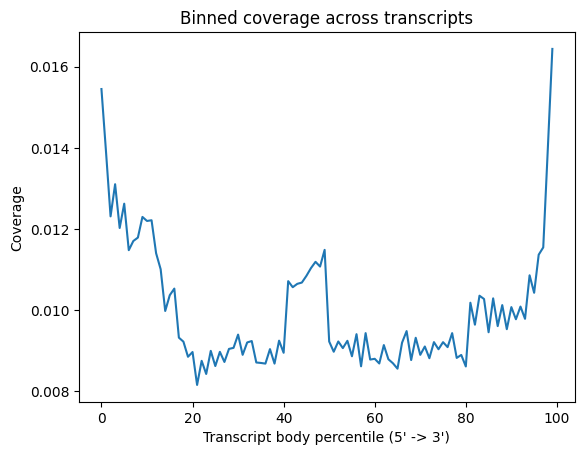

In [26]:
# sample 1000 random transcripts from transcripts_with_coverage 
transcripts_with_coverage_samp = np.random.choice(transcripts_with_coverage, 30000)

# subset transcript_coverage to only include transcripts with coverage
transcript_coverage_subset = {transcript: coverage for transcript, coverage in transcript_coverage.items() if transcript in transcripts_with_coverage_samp}

average_coverage_bins = bin_coverage(transcript_coverage_subset, transcript_coordinates)

plot_binned_coverage(average_coverage_bins)